In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import TargetEncoder

In [2]:
data = pd.read_csv(r"C:\Users\ankit\Downloads\car_price_prediction.csv")

In [3]:
data

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [5]:
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [6]:
data.drop(columns= ["ID","Doors"],inplace=True)

In [7]:
data.head(3)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,Right-hand drive,Black,2


In [8]:
data.Levy  = data.Levy.replace("-",np.nan)

In [9]:
data.Levy = pd.to_numeric(data.Levy)
data.Levy = data.Levy.fillna(value=int(data.Levy.mean())).astype(int)

In [10]:
data.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,Left wheel,Black,8
2,8467,906,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,Left wheel,Silver,4


In [11]:
data["Mileage"] = data["Mileage"].str.replace(" km", "")
data["Mileage"] = pd.to_numeric(data["Mileage"])

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             19237 non-null  int64  
 1   Levy              19237 non-null  int64  
 2   Manufacturer      19237 non-null  object 
 3   Model             19237 non-null  object 
 4   Prod. year        19237 non-null  int64  
 5   Category          19237 non-null  object 
 6   Leather interior  19237 non-null  object 
 7   Fuel type         19237 non-null  object 
 8   Engine volume     19237 non-null  object 
 9   Mileage           19237 non-null  int64  
 10  Cylinders         19237 non-null  float64
 11  Gear box type     19237 non-null  object 
 12  Drive wheels      19237 non-null  object 
 13  Wheel             19237 non-null  object 
 14  Color             19237 non-null  object 
 15  Airbags           19237 non-null  int64  
dtypes: float64(1), int64(5), object(10)
memo

In [13]:
data.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000,6.0,Tiptronic,4x4,Left wheel,Black,8
2,8467,906,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,Left wheel,Silver,4


In [14]:
data["Engine volume"] = data["Engine volume"].str.replace("Turbo", "")
data["Engine volume"] = pd.to_numeric(data["Engine volume"])

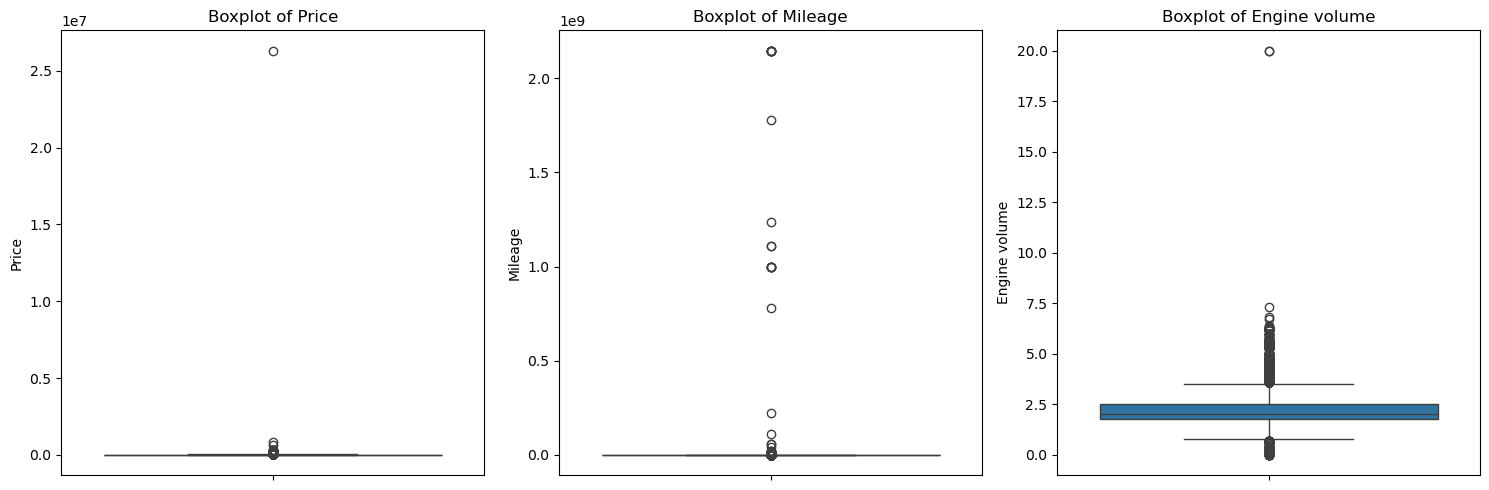

In [15]:
columns_to_plot = ['Price', 'Mileage', 'Engine volume']

plt.figure(figsize=(15, 5))
for i, column in enumerate(columns_to_plot):
    plt.subplot(1, len(columns_to_plot), i + 1)
    sns.boxplot(y=data[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

In [16]:
data.Price.skew()

np.float64(136.4704265426872)

In [18]:
data.duplicated().sum()

np.int64(3512)

In [19]:
data.drop_duplicates(inplace=True)

In [20]:
data.Price.skew()

np.float64(123.63407135708886)

In [24]:
data["Price_log"] = np.log(data["Price"])
print(data["Price_log"].skew())

-1.8175825738238933


In [23]:
data["Price_log"] = np.log1p(data["Price"])
print(data["Price_log"].skew())

-1.7938697666327588


<Axes: ylabel='Price_log'>

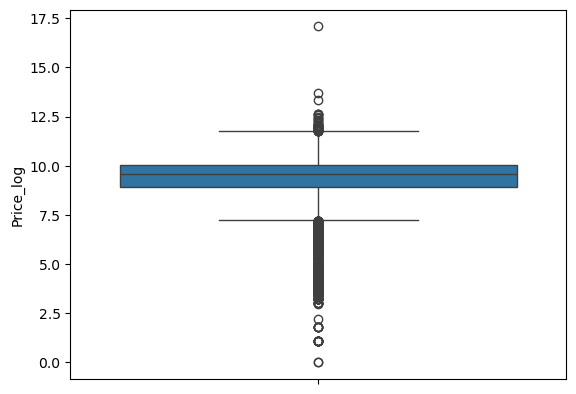

In [25]:
sns.boxplot(y=data["Price_log"])

In [ ]:
#apply outliers for price_log #

In [26]:
Q1 = data["Price_log"].quantile(0.25)
Q3 = data["Price_log"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = data[(data["Price_log"] >= lower_bound) & (data["Price_log"] <= upper_bound)]

In [27]:
data.shape , df_clean.shape

((15725, 17), (14125, 17))

<Axes: ylabel='Price_log'>

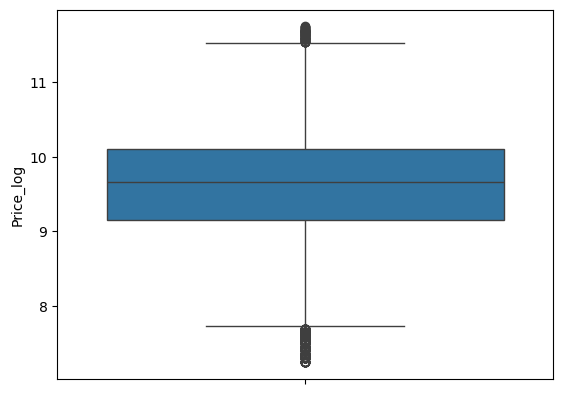

In [28]:
sns.boxplot(y=df_clean["Price_log"])

<Axes: >

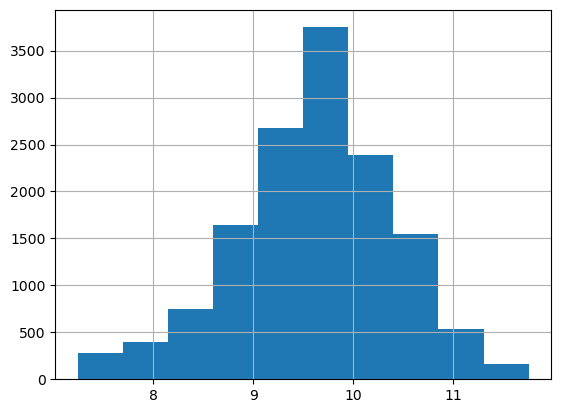

In [29]:
df_clean["Price_log"].hist()

<Axes: ylabel='Mileage'>

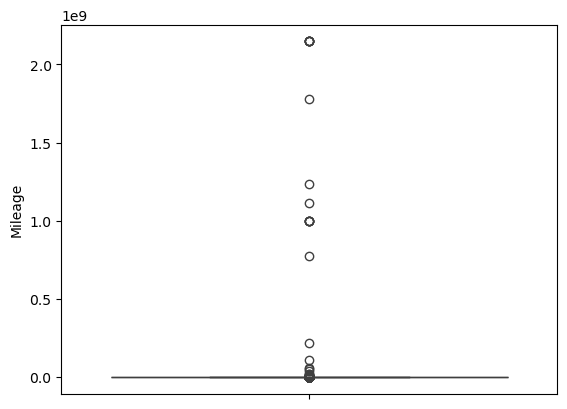

In [30]:
sns.boxplot(y=df_clean["Mileage"])

In [32]:
df_clean["Mileage"].skew()

np.float64(35.59856847357023)

In [37]:
df_clean["Mileage_log"] = np.log1p(df_clean["Mileage"])

C:\Users\ankit\AppData\Local\Temp\ipykernel_19204\3502538242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Mileage_log"] = np.log1p(df_clean["Mileage"])


In [38]:
df_clean["Mileage_log"].skew()

np.float64(-3.6879460889107385)

<Axes: ylabel='Mileage_log'>

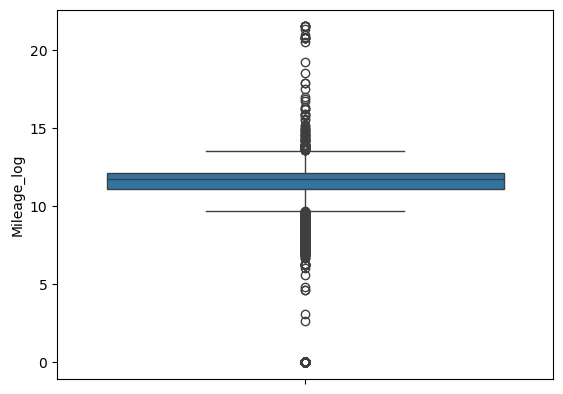

In [39]:
sns.boxplot(y=df_clean["Mileage_log"])

In [40]:
Q1 = df_clean["Price_log"].quantile(0.25)
Q3 = df_clean["Price_log"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean["Price_log"] >= lower_bound) & (df_clean["Price_log"] <= upper_bound)]

In [41]:
df_clean.shape

(13787, 18)

<Axes: ylabel='Mileage_log'>

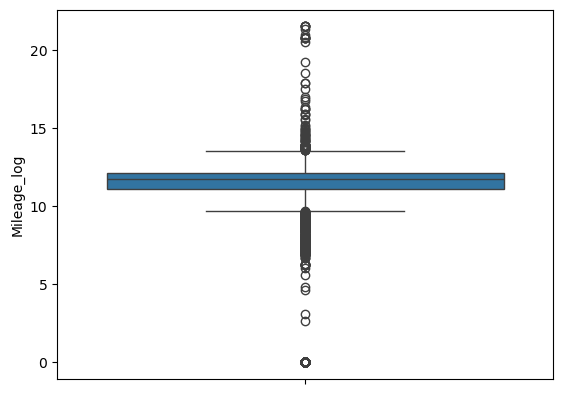

In [42]:
sns.boxplot(y=df_clean["Mileage_log"])

In [43]:
df_clean.Mileage_log.skew()

np.float64(-3.7272334319411926)

<Axes: ylabel='Engine volume'>

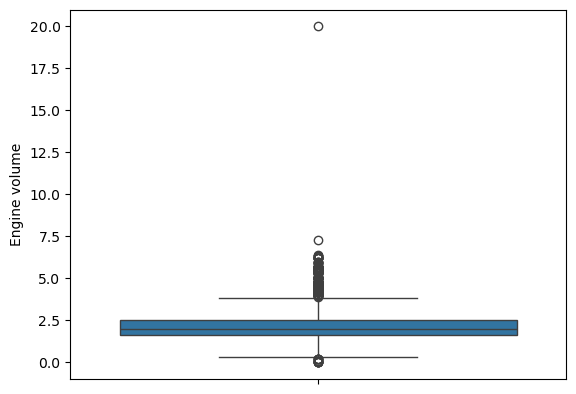

In [44]:
sns.boxplot(y=df_clean["Engine volume"])

In [45]:
df_clean["Engine volume"].skew()

np.float64(2.483880146556732)

In [46]:
df_clean["Volume_log"] = np.log(df_clean["Engine volume"])

C:\Users\ankit\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [47]:
df_clean["Volume_log"] = np.log1p(df_clean["Engine volume"])

In [48]:
df_clean["Volume_log"].skew()

np.float64(0.8088368863708492)

<Axes: ylabel='Volume_log'>

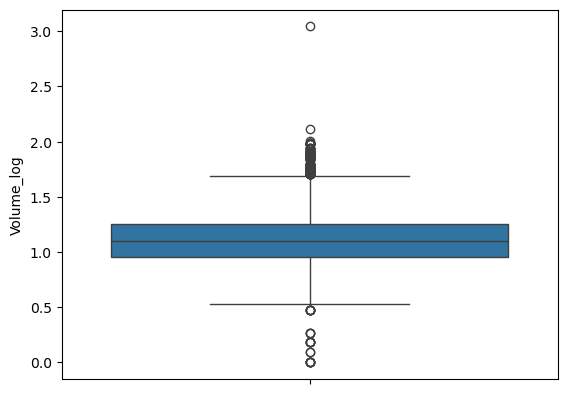

In [49]:
sns.boxplot(y=df_clean["Volume_log"])

In [50]:
df_clean.shape

(13787, 19)

In [51]:
Q1 = df_clean["Volume_log"].quantile(0.25)
Q3 = df_clean["Volume_log"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean["Volume_log"] >= lower_bound) & (df_clean["Volume_log"] <= upper_bound)]

In [52]:
df_clean.shape

(13419, 19)

<Axes: ylabel='Volume_log'>

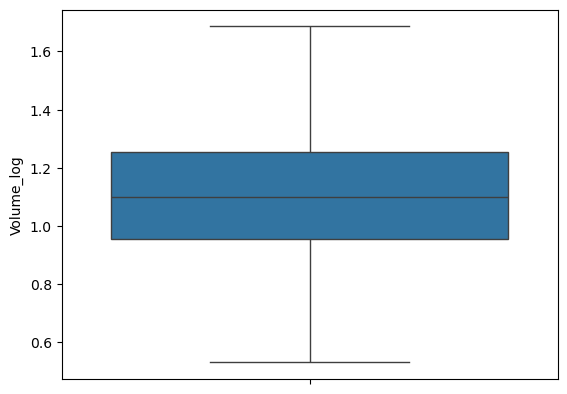

In [53]:
sns.boxplot(y=df_clean["Volume_log"])

In [56]:
df_clean.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags,Price_log,Mileage_log,Volume_log
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,Left wheel,Silver,12,9.497622,12.133534,1.504077
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,Left wheel,Black,8,9.718422,12.165256,1.386294
2,8467,906,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,Right-hand drive,Black,2,9.043932,12.206078,0.832909
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,Left wheel,White,0,8.190632,12.037459,1.252763
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,Left wheel,Silver,4,9.369564,11.428478,0.832909


In [57]:
data = df_clean.drop(columns=["Model","Price","Mileage","Engine volume"])

In [58]:
data.head()

,Levy,Manufacturer,Prod. year,Category,Leather interior,Fuel type,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags,Price_log,Mileage_log,Volume_log
0,1399,LEXUS,2010,Jeep,Yes,Hybrid,6.0,Automatic,4x4,Left wheel,Silver,12,9.497622,12.133534,1.504077
1,1018,CHEVROLET,2011,Jeep,No,Petrol,6.0,Tiptronic,4x4,Left wheel,Black,8,9.718422,12.165256,1.386294
2,906,HONDA,2006,Hatchback,No,Petrol,4.0,Variator,Front,Right-hand drive,Black,2,9.043932,12.206078,0.832909
3,862,FORD,2011,Jeep,Yes,Hybrid,4.0,Automatic,4x4,Left wheel,White,0,8.190632,12.037459,1.252763
4,446,HONDA,2014,Hatchback,Yes,Petrol,4.0,Automatic,Front,Left wheel,Silver,4,9.369564,11.428478,0.832909


<Axes: xlabel='count', ylabel='Manufacturer'>

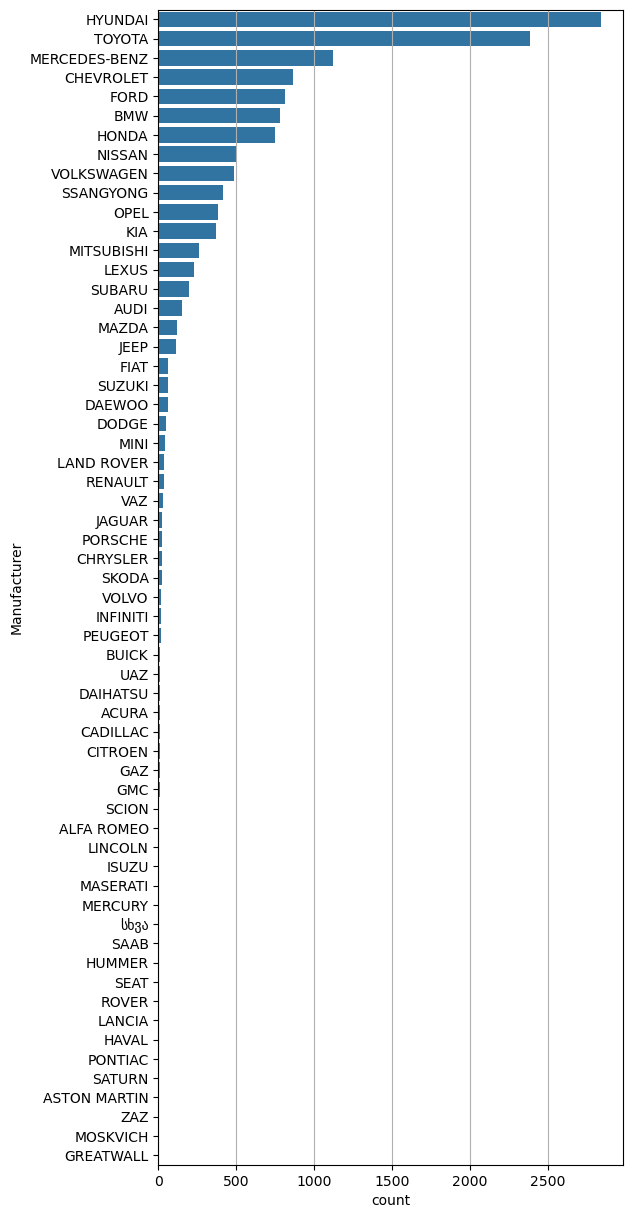

In [59]:
plt.figure(figsize=(6, 15))
plt.grid()
sns.barplot(data.Manufacturer.value_counts(),orient="y")

In [60]:
rare = data.Manufacturer.value_counts()

In [61]:
Others =  list(dict(rare[rare < 50]).keys())
data.Manufacturer = data.Manufacturer.apply(lambda x: "Others" if x in Others else x)

In [62]:
data.Manufacturer.value_counts()

Manufacturer
HYUNDAI          2845
TOYOTA           2386
MERCEDES-BENZ    1123
CHEVROLET         863
FORD              816
BMW               778
HONDA             749
NISSAN            502
VOLKSWAGEN        486
SSANGYONG         414
Others            395
OPEL              383
KIA               367
MITSUBISHI        264
LEXUS             229
SUBARU            196
AUDI              152
MAZDA             119
JEEP              114
FIAT               64
SUZUKI             63
DAEWOO             61
DODGE              50
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Manufacturer'>

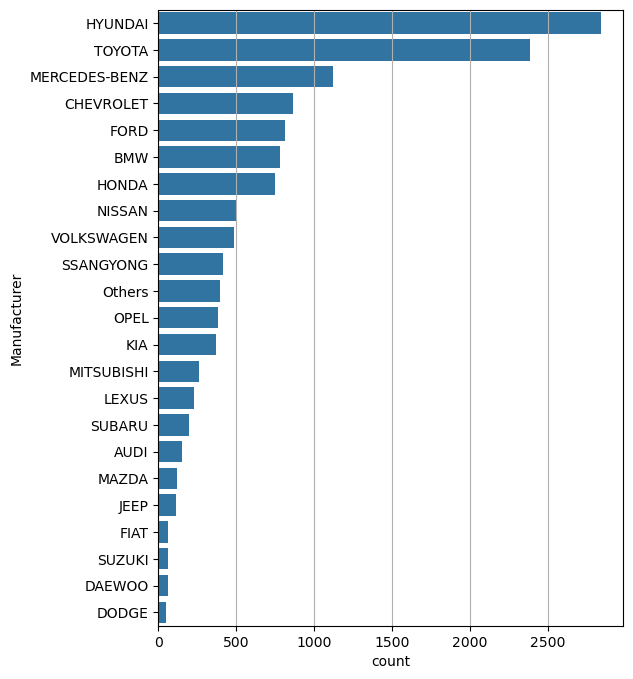

In [63]:
plt.figure(figsize=(6, 8))
plt.grid()
sns.barplot(data.Manufacturer.value_counts(),orient="y")

In [65]:
data.head(3)

,Levy,Manufacturer,Prod. year,Category,Leather interior,Fuel type,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags,Price_log,Mileage_log,Volume_log
0,1399,LEXUS,2010,Jeep,Yes,Hybrid,6.0,Automatic,4x4,Left wheel,Silver,12,9.497622,12.133534,1.504077
1,1018,CHEVROLET,2011,Jeep,No,Petrol,6.0,Tiptronic,4x4,Left wheel,Black,8,9.718422,12.165256,1.386294
2,906,HONDA,2006,Hatchback,No,Petrol,4.0,Variator,Front,Right-hand drive,Black,2,9.043932,12.206078,0.832909


In [66]:
data["Prod. year"].value_counts()

Prod. year
2012    1430
2014    1340
2013    1335
2016    1063
2015    1050
2011    1011
2010     932
2017     632
2008     471
2009     429
2007     402
2018     334
2005     328
2004     305
2003     301
2000     259
2006     258
2002     254
2001     230
1999     191
1998     187
2019     162
1997     142
1996      98
1995      94
1994      37
2020      37
1992      27
1993      20
1990      12
1991      10
1988       8
1989       5
1986       5
1987       5
1985       3
1953       3
1977       2
1964       2
1984       1
1957       1
1980       1
1982       1
1981       1
Name: count, dtype: int64

In [67]:
scaler = StandardScaler()
data["Levy"] = scaler.fit_transform(data[["Levy"]])
data["Prod. year"] = scaler.fit_transform(data[["Prod. year"]])
data["Cylinders"] = scaler.fit_transform(data[["Cylinders"]])
data["Airbags"] = scaler.fit_transform(data[["Airbags"]])
data["Volume_log"] = scaler.fit_transform(data[["Volume_log"]])
data["Mileage_log"] = scaler.fit_transform(data[["Mileage_log"]])
data["Price_log"] = scaler.fit_transform(data[["Price_log"]])

In [68]:
data.head()

,Levy,Manufacturer,Prod. year,Category,Leather interior,Fuel type,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags,Price_log,Mileage_log,Volume_log
0,1.837600,LEXUS,-0.076539,Jeep,Yes,Hybrid,1.738319,Automatic,4x4,Left wheel,Silver,1.533405,-0.200953,0.422354,2.070815
1,0.524311,CHEVROLET,0.094555,Jeep,No,Petrol,1.738319,Tiptronic,4x4,Left wheel,Black,0.483383,0.106481,0.436160,1.439571
2,0.138252,HONDA,-0.760914,Hatchback,No,Petrol,-0.379769,Variator,Front,Right-hand drive,Black,-1.091651,-0.832657,0.453926,-1.526232
3,-0.013414,FORD,0.094555,Jeep,Yes,Hybrid,-0.379769,Automatic,4x4,Left wheel,White,-1.616662,-2.020763,0.380540,0.723925
4,-1.447346,HONDA,0.607836,Hatchback,Yes,Petrol,-0.379769,Automatic,Front,Left wheel,Silver,-0.566640,-0.379258,0.115500,-1.526232


In [69]:
data.columns

Index(['Levy', 'Manufacturer', 'Prod. year', 'Category', 'Leather interior',
       'Fuel type', 'Cylinders', 'Gear box type', 'Drive wheels', 'Wheel',
       'Color', 'Airbags', 'Price_log', 'Mileage_log', 'Volume_log'],
      dtype='object')

In [92]:
x= data[['Levy', 'Manufacturer', 'Prod. year', 'Category', 'Leather interior',
       'Fuel type', 'Cylinders', 'Gear box type', 'Drive wheels', 'Wheel',
       'Color', 'Airbags', 'Mileage_log', 'Volume_log']]
y = data["Price_log"]

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [94]:
cat_cols = x.select_dtypes(include='object').columns

In [95]:
encoder = TargetEncoder()
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [96]:
### SVR

svr = SVR(kernel="rbf",
        C=300,
        epsilon=0.5)
svr.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,300
,epsilon,0.5
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [75]:
predicted = svr.predict(X_test)

In [97]:
mean_squared_error(y_test,predicted)

0.41547455567179103

In [77]:
r2_score(y_test,predicted)

0.5880367203462225

In [78]:
## Descision tree
tree = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    random_state=42)
tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [79]:
pred = tree.predict(X_test)

In [80]:
mean_squared_error(y_test,pred)

0.427164316794592

In [81]:
r2_score(y_test,pred)

0.5764457522236823

In [82]:
## Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [83]:
pred2 = lr.predict(X_test)

In [84]:
mean_squared_error(y_test,pred2)

0.6151786583072006

In [85]:
lasso = Lasso()
lasso.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [86]:
pred = lasso.predict(X_test)

In [87]:
mean_squared_error(y_test,pred)

1.0085233161508136

In [88]:
r2_score(y_test,pred)

-4.153564003850363e-08

In [89]:
ridge = Ridge()
ridge.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [90]:
pred = ridge.predict(X_test)
mean_squared_error(pred,y_test)

0.6150710680160821

In [91]:
r2_score(pred,y_test)

-0.4453266655753849